#  Algeria Export Opportunity — Classification
Classify every country-product pair into **High / Medium / Low** export opportunity.

| | Model |
|---|---|
| **MODEL 1** | Random Forest |
| **MODEL 2** | XGBoost |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import gc

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Classification Data

We sample from 8 spread-out row groups (every ~20th) to get a representative cross-section without loading the full dataset into RAM.  
Each row group is capped at 100 000 rows before concatenation.

In [2]:
import os

MASTER = "algeria_trade_master_sample_2M_clean.parquet"
if not os.path.exists(MASTER):
    MASTER = r"c:\Users\nabip\Downloads\miaw\algeria_trade_master_sample_2M_clean.parquet"

print(f"Loading data from: {MASTER}")
pf = pq.ParquetFile(MASTER)

needed_cols = [
    "year",  # Required for temporal splitting
    "global_demand_index",
    "market_share",
    "penetration_ratio",
    "export_growth",
    "gdp",
    "global_imports",
    "hhi",
    "product_diversity",
    "fobvalue",
    "opportunity_level"
]

# Memory-efficient read of only required columns for the entire dataset
df = pf.read(columns=needed_cols).to_pandas()
print(f"Dataset loaded. Shape: {df.shape}")



Loading data from: algeria_trade_master_sample_2M_clean.parquet
Dataset loaded. Shape: (1994604, 11)


## 3. Target Variable Distribution

Before encoding, visualise how the three classes are balanced.  
A strong imbalance will inform our sample-weighting strategy below.

C:\Users\nabip\AppData\Local\Temp\ipykernel_32380\1226447704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


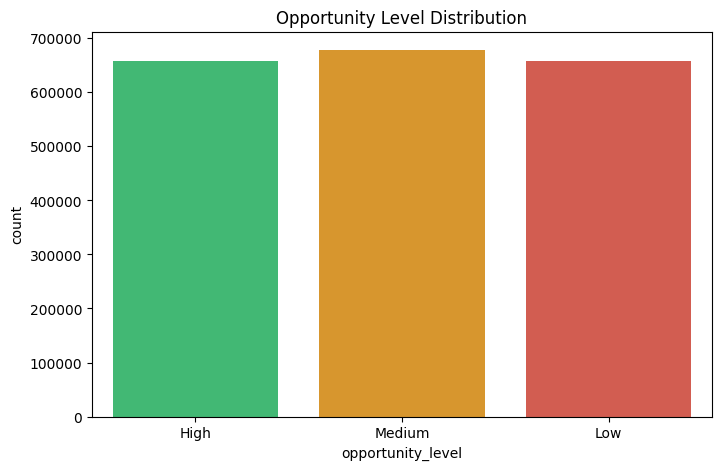

opportunity_level
Medium    678143
Low       658426
High      658035
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="opportunity_level",
    order=["High","Medium","Low"],
    palette=["#2ecc71","#f39c12","#e74c3c"]
)

plt.title("Opportunity Level Distribution")

plt.show()

print(df["opportunity_level"].value_counts())

## 4. Encode Target Label

`LabelEncoder` maps string labels to integers (alphabetical order by default).  
We print `encoder.classes_` so the integer-to-label mapping is always explicit.

In [4]:
encoder = LabelEncoder()

df["target"] = encoder.fit_transform(
    df["opportunity_level"]
)

print("Encoded classes (index = integer label):")
print(encoder.classes_)

Encoded classes (index = integer label):
['High' 'Low' 'Medium']


## 5. Define Features & Target

In [5]:
features = [
    "global_demand_index",  # Retained (world_imports is dropped as 93.8% correlated)
    "market_share",
    "penetration_ratio",
    "export_growth",
    "gdp",
    "global_imports",
    "hhi",
    "product_diversity",
    "fobvalue"  # Retained (trade_balance is dropped as 100% identical)
]

X = df[features]
y = df["target"]
print("Features:", features)



Features: ['global_demand_index', 'market_share', 'penetration_ratio', 'export_growth', 'gdp', 'global_imports', 'hhi', 'product_diversity', 'fobvalue']


## 6. Train / Validation / Test Split

We create **three** splits:
- **Train** (68 %) — model fitting  
- **Validation** (12 %) — early stopping for XGBoost (never touches the test set)  
- **Test** (20 %) — final unbiased evaluation for both models

Using the test set for early stopping leaks evaluation signal into training decisions and inflates reported performance — the validation set prevents this.

In [6]:
# Splitting data by year to prevent temporal data leakage:
# Train: Years 2010 - 2022
# Val: Year 2023 (for XGBoost early stopping)
# Test: Year 2024 (for final unbiased evaluation)

train_mask = df["year"] <= 2022
val_mask = df["year"] == 2023
test_mask = df["year"] == 2024

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train (2010-2022) : {X_train.shape}")
print(f"Val (2023)        : {X_val.shape}")
print(f"Test (2024)       : {X_test.shape}")

print("\nClass distribution (train):")
print(
    y_train.map(dict(enumerate(encoder.classes_))).value_counts(normalize=True).round(4) * 100
)
print("\nClass distribution (val):")
print(
    y_val.map(dict(enumerate(encoder.classes_))).value_counts(normalize=True).round(4) * 100
)
print("\nClass distribution (test):")
print(
    y_test.map(dict(enumerate(encoder.classes_))).value_counts(normalize=True).round(4) * 100
)



Train (2010-2022) : (1698824, 9)
Val (2023)        : (152131, 9)
Test (2024)       : (143649, 9)

Class distribution (train):


target
Medium    34.00
Low       33.01
High      32.99
Name: proportion, dtype: float64

Class distribution (val):
target
Medium    34.00
Low       33.01
High      32.99
Name: proportion, dtype: float64

Class distribution (test):
target
Medium    33.99
Low       33.02
High      32.99
Name: proportion, dtype: float64


## 7. Compute Sample Weights

`compute_sample_weight('balanced')` assigns each training row a weight inversely proportional to its class frequency.  
Both models accept this via their `sample_weight` / `class_weight` arguments, it directly tackles the Medium class under-recall problem.

In [7]:
# The dataset is now balanced (~33% for each class), so sample weighting is no longer necessary.
# We define a dummy weight variable as 1.0 for compatibility, or simply omit it.
print("Classes are balanced. Sample weighting is disabled.")



Classes are balanced. Sample weighting is disabled.


---
## MODEL 1 — Random Forest

Random Forest builds many decorrelated decision trees in parallel and averages their votes.  
It is robust to noisy features, requires minimal tuning, and provides reliable feature importances.

| Parameter | Value | Change | Reason |
|---|---|---|---|
| `n_estimators` | 200 | — | More trees = more stable predictions |
| `max_depth` | **7** | ↓ from 10 | Shallower trees generalise better on large data |
| `min_samples_leaf` | **100** | ↑ from 20 | On a large dataset, 20 samples/leaf is nearly nothing; 100 forces meaningful splits |
| `max_features` | **0.5** | new | Each split only sees 50 % of features — reduces correlation between trees |
| `class_weight` | balanced | — | Compensates for class imbalance |
| `n_jobs` | -1 | — | Uses all available CPU cores |

### 8.1. Train Random Forest

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # ↓ from 200 to speed up training on 1.7M rows
    max_depth=7,
    min_samples_leaf=100,
    max_features=0.5,
    class_weight=None,     # Removed since classes are balanced
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest ...")
rf_model.fit(X_train, y_train)
print("Done.")



Training Random Forest ...


Done.


### 8.2. Random Forest : Accuracy & Classification Report

In [9]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print(f"Accuracy: {rf_acc:.4f}")
print()
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=encoder.classes_
    )
)

Accuracy: 0.9068

              precision    recall  f1-score   support

        High       0.90      0.96      0.93     47387
         Low       0.95      0.91      0.93     47433
      Medium       0.87      0.86      0.86     48829

    accuracy                           0.91    143649
   macro avg       0.91      0.91      0.91    143649
weighted avg       0.91      0.91      0.91    143649



### 8.3. Random Forest : Confusion Matrix

Rows = actual class, Columns = predicted class.  
Off-diagonal values show where the model confuses one class for another.

<Figure size 700x500 with 0 Axes>

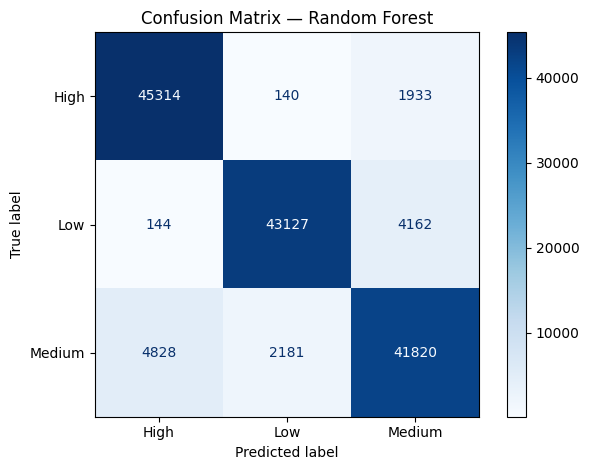

In [10]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))

ConfusionMatrixDisplay(
    cm_rf,
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

### 8.4. Random Forest : ROC AUC

`multi_class='ovr'` computes one-vs-rest AUC for each class and macro-averages them.  
A score above 0.85 is generally considered good for a 3-class problem.

In [11]:
rf_prob = rf_model.predict_proba(X_test)

rf_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print(f"ROC AUC: {rf_auc:.4f}")

ROC AUC: 0.9819


### 8.5. Random Forest : Feature Importance

Mean decrease in impurity (Gini) across all trees.

,feature,importance
3,export_growth,0.378937
2,penetration_ratio,0.205899
4,gdp,0.195079
1,market_share,0.154190
5,global_imports,0.036533
0,global_demand_index,0.022499
8,fobvalue,0.004778
7,product_diversity,0.001906
6,hhi,0.000179


C:\Users\nabip\AppData\Local\Temp\ipykernel_32380\2859013017.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


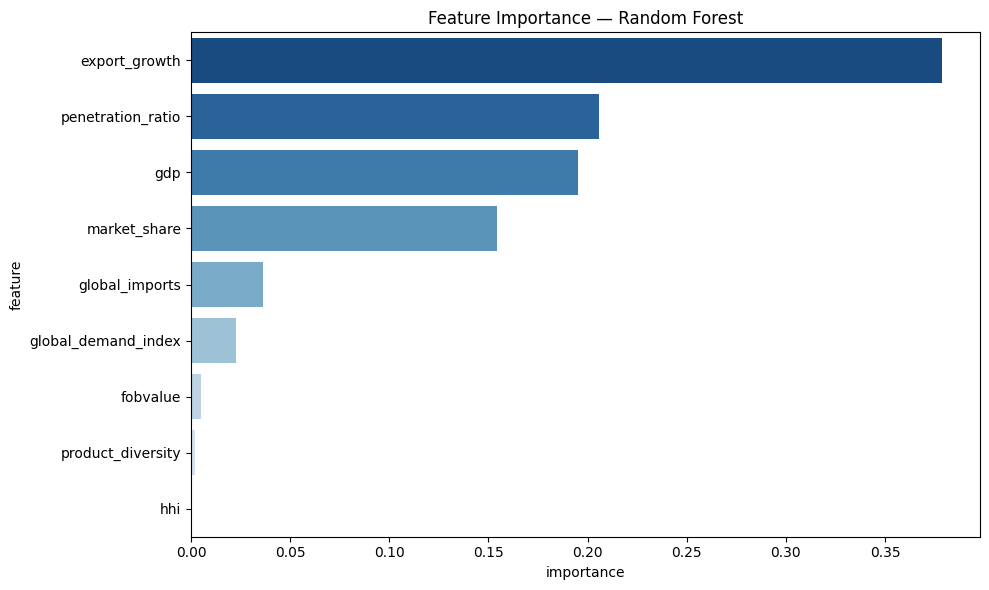

In [12]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance,
    x="importance",
    y="feature",
    palette="Blues_r"
)

plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

---
## MODEL 2 — XGBoost

XGBoost builds trees **sequentially**, each one correcting the errors of the previous.  
It typically outperforms Random Forest on tabular data and trains faster with `tree_method='hist'`.

| Parameter | Value | Change | Reason |
|---|---|---|---|
| `n_estimators` | 500 | — | Upper bound; early stopping cuts this short |
| `max_depth` | **5** | ↓ from 8 | Shallower trees, less memorisation |
| `learning_rate` | 0.05 | — | Low LR + many trees → better generalisation |
| `subsample` | **0.7** | ↓ from 0.8 | More aggressive row subsampling |
| `colsample_bytree` | **0.6** | ↓ from 0.8 | Fewer features per tree |
| `reg_alpha` | **0.1** | new | L1 regularisation — encourages sparse feature use |
| `reg_lambda` | **5.0** | new | L2 regularisation — penalises large leaf weights |
| `min_child_weight` | **50** | new | Requires 50 samples in a leaf before splitting — prunes tiny branches |
| `early_stopping_rounds` | 30 | — | Stops if **validation** loss doesn't improve for 30 rounds |

### 9.1. Train XGBoost

Training XGBoost ...


[0]	validation_0-mlogloss:1.06285	validation_1-mlogloss:1.06313


[50]	validation_0-mlogloss:0.42647	validation_1-mlogloss:0.43116


[100]	validation_0-mlogloss:0.28289	validation_1-mlogloss:0.28801


[150]	validation_0-mlogloss:0.21566	validation_1-mlogloss:0.22118


...

[350]	validation_0-mlogloss:0.13712	validation_1-mlogloss:0.14878


[400]	validation_0-mlogloss:0.12958	validation_1-mlogloss:0.14271


[450]	validation_0-mlogloss:0.12384	validation_1-mlogloss:0.13795


[499]	validation_0-mlogloss:0.11876	validation_1-mlogloss:0.13370



Best iteration: 499


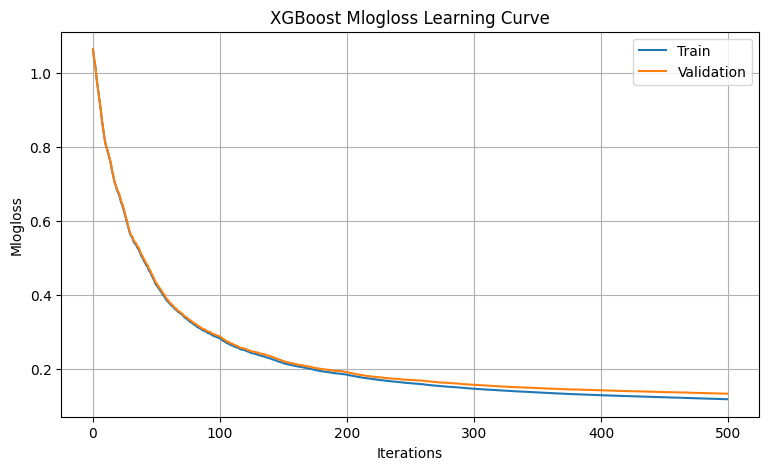

In [13]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=5.0,
    min_child_weight=50,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=42
)

print("Training XGBoost ...")

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # Track train and val loss to plot learning curves
    verbose=50
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

# Plot learning curves
results = xgb_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(9, 5))
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
plt.legend()
plt.ylabel('Mlogloss')
plt.xlabel('Iterations')
plt.title('XGBoost Mlogloss Learning Curve')
plt.grid(True)
plt.show()



### 9.2. XGBoost : Accuracy & Classification Report

In [14]:
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"Accuracy: {xgb_acc:.4f}")
print()
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=encoder.classes_
    )
)

Accuracy: 0.9433

              precision    recall  f1-score   support

        High       0.91      0.99      0.95     47387
         Low       1.00      0.93      0.96     47433
      Medium       0.93      0.90      0.92     48829

    accuracy                           0.94    143649
   macro avg       0.95      0.94      0.94    143649
weighted avg       0.95      0.94      0.94    143649



### 9.3. XGBoost : Confusion Matrix

<Figure size 700x500 with 0 Axes>

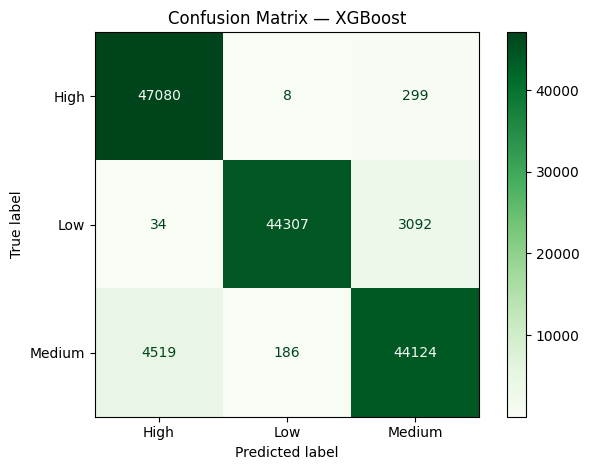

In [15]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(7,5))

ConfusionMatrixDisplay(
    cm_xgb,
    display_labels=encoder.classes_
).plot(cmap="Greens")

plt.title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

### 9.4. XGBoost : ROC AUC

In [16]:
xgb_prob = xgb_model.predict_proba(X_test)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print(f"ROC AUC: {xgb_auc:.4f}")

ROC AUC: 0.9948


### 9.5. XGBoost : Feature Importance

Gain-based importance — how much each feature reduces loss across all splits.

,feature,importance
3,export_growth,0.279693
4,gdp,0.182850
1,market_share,0.150946
2,penetration_ratio,0.145474
5,global_imports,0.111629
0,global_demand_index,0.054104
8,fobvalue,0.050819
7,product_diversity,0.022632
6,hhi,0.001854


C:\Users\nabip\AppData\Local\Temp\ipykernel_32380\800193715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


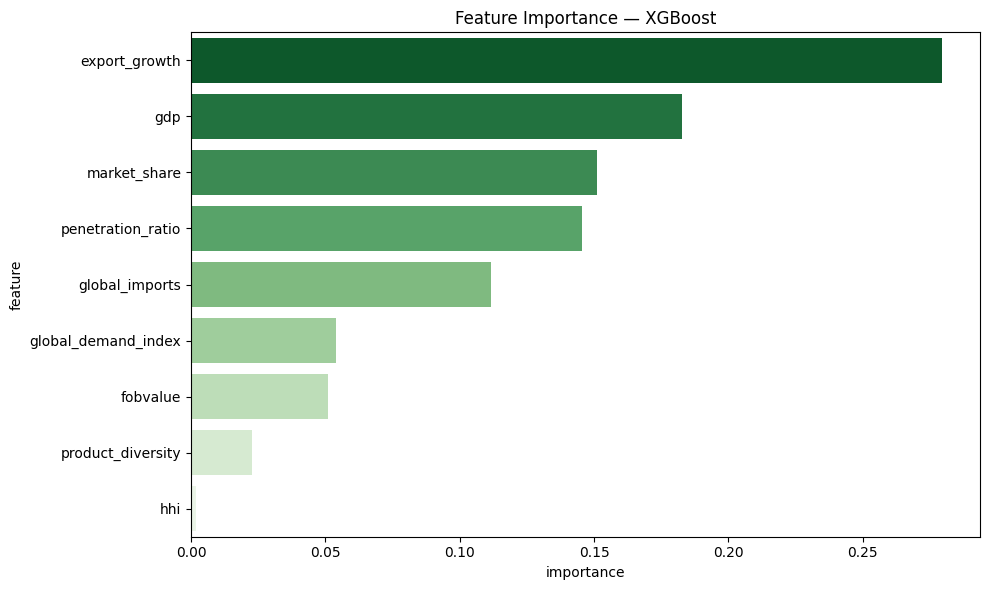

In [17]:
xgb_importance = pd.DataFrame({
    "feature": features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(xgb_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x="importance",
    y="feature",
    palette="Greens_r"
)

plt.title("Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

---
## 10. Cross-Validation — Generalisation Check

`StratifiedKFold` with 5 folds gives a more reliable performance estimate than a single train/test split.  
A high standard deviation across folds signals that results are sensitive to the particular split chosen —
especially relevant here since we sampled only 8 row groups from a much larger file.

We run CV on the **full sampled dataset** (not just X_train) to use all available data.

Running 5-fold CV on stratified 10% subsample (199461 rows)...
Running CV for Random Forest ...


RF   CV F1 (weighted): 0.9083 ± 0.0011

Running CV for XGBoost ...


XGB  CV F1 (weighted): 0.9282 ± 0.0008


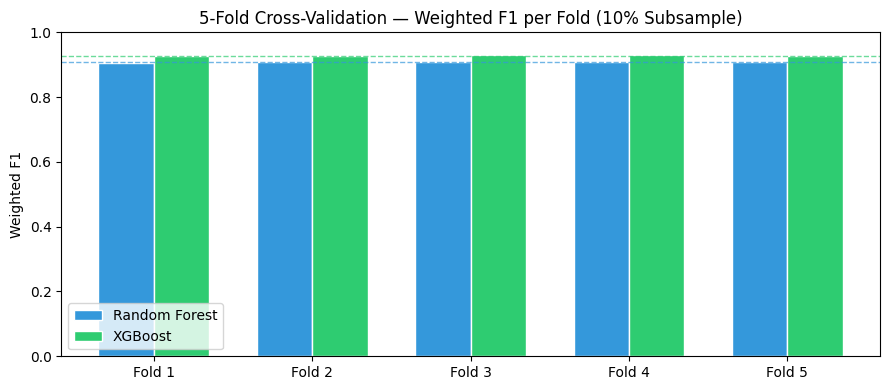

In [18]:
# Since running 5-fold CV on 2M samples is computationally expensive,
# we run it on a representative stratified 10% subsample (approx. 200,000 samples)
# to evaluate generalization and stability efficiently.
from sklearn.model_selection import train_test_split

_, X_cv_sub, _, y_cv_sub = train_test_split(
    X, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Running 5-fold CV on stratified 10% subsample ({X_cv_sub.shape[0]} rows)...")
print("Running CV for Random Forest ...")
rf_cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=50,       # fewer trees for speed during CV
        max_depth=7,
        min_samples_leaf=100,
        max_features=0.5,
        class_weight=None,
        n_jobs=-1,
        random_state=42
    ),
    X_cv_sub, y_cv_sub,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print(f"RF   CV F1 (weighted): {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

print("\nRunning CV for XGBoost ...")
xgb_cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100,      # fewer trees for speed during CV
        max_depth=5,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_alpha=0.1,
        reg_lambda=5.0,
        min_child_weight=50,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=42
    ),
    X_cv_sub, y_cv_sub,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print(f"XGB  CV F1 (weighted): {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

# Visualise fold-by-fold scores
fig, ax = plt.subplots(figsize=(9, 4))
folds = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)
width = 0.35
ax.bar(x - width/2, rf_cv_scores,  width, label="Random Forest", color="#3498db", edgecolor="white")
ax.bar(x + width/2, xgb_cv_scores, width, label="XGBoost",       color="#2ecc71", edgecolor="white")
ax.axhline(rf_cv_scores.mean(),  color="#3498db", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(xgb_cv_scores.mean(), color="#2ecc71", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel("Weighted F1")
ax.set_title("5-Fold Cross-Validation — Weighted F1 per Fold (10% Subsample)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()



---
## 11. Model Comparison

Side-by-side summary of both models.  
**Weighted F1** is the primary metric here because the classes are not perfectly balanced.

,Model,Accuracy,Weighted F1,ROC AUC
0,Random Forest,0.906801,0.906605,0.981885
1,XGBoost,0.943348,0.943321,0.994829


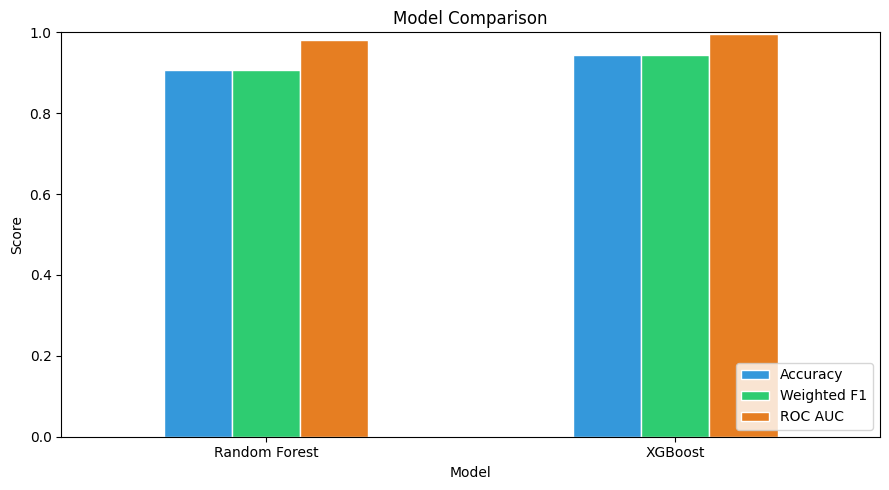

In [19]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": rf_acc,
        "Weighted F1": f1_score(y_test, rf_pred, average="weighted"),
        "ROC AUC": rf_auc
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_acc,
        "Weighted F1": f1_score(y_test, xgb_pred, average="weighted"),
        "ROC AUC": xgb_auc
    }
])

display(comparison)

comparison.set_index("Model")[["Accuracy","Weighted F1","ROC AUC"]].plot(
    kind="bar",
    figsize=(9,5),
    color=["#3498db","#2ecc71","#e67e22"],
    rot=0,
    ylim=(0,1),
    edgecolor="white"
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 12. Prediction Distribution

Compare predicted class counts against the actual distribution (Cell 3).  
Large differences signal that a model is systematically over- or under-predicting a class.

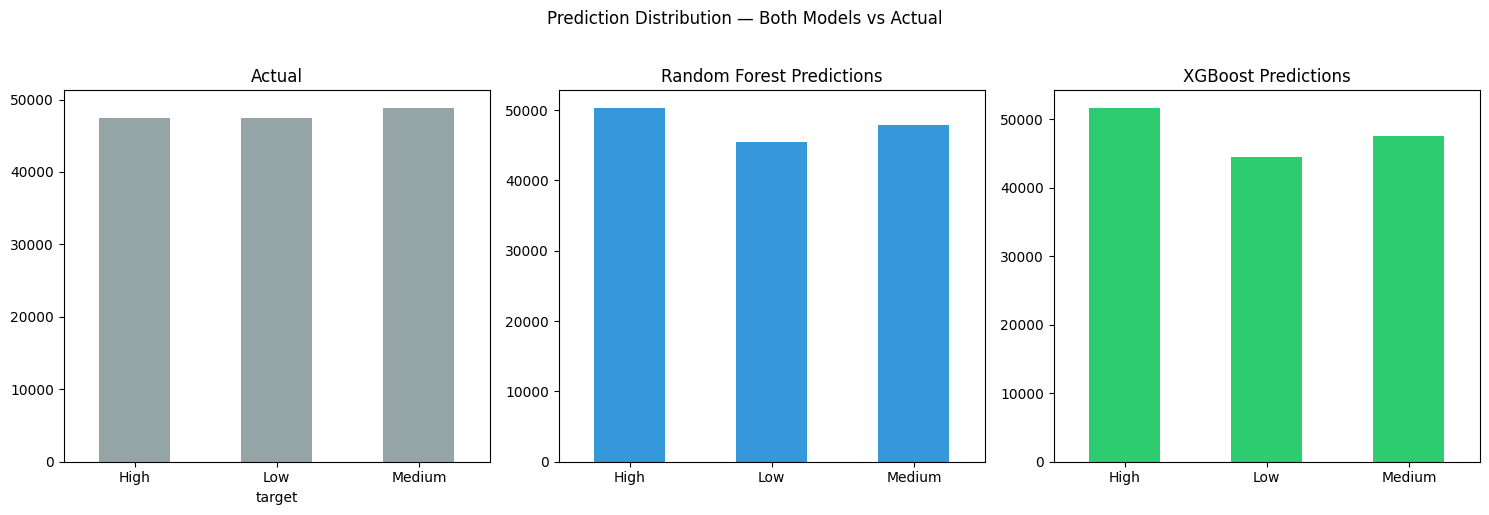

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Actual
pd.Series(y_test)    .map(dict(enumerate(encoder.classes_)))    .value_counts()    .reindex(encoder.classes_)    .plot(kind="bar", ax=axes[0], color="#95a5a6")
axes[0].set_title("Actual")
axes[0].set_xticklabels(encoder.classes_, rotation=0)

# Random Forest predictions
pd.Series(rf_pred)    .map(dict(enumerate(encoder.classes_)))    .value_counts()    .reindex(encoder.classes_)    .plot(kind="bar", ax=axes[1], color="#3498db")
axes[1].set_title("Random Forest Predictions")
axes[1].set_xticklabels(encoder.classes_, rotation=0)

# XGBoost predictions
pd.Series(xgb_pred)    .map(dict(enumerate(encoder.classes_)))    .value_counts()    .reindex(encoder.classes_)    .plot(kind="bar", ax=axes[2], color="#2ecc71")
axes[2].set_title("XGBoost Predictions")
axes[2].set_xticklabels(encoder.classes_, rotation=0)

plt.suptitle("Prediction Distribution — Both Models vs Actual", y=1.02)
plt.tight_layout()
plt.show()

## 13. Prediction Confidence Distribution

Histogram of `max(predict_proba)` for each model.  
A well-calibrated model peaks toward 1.0; a flat or left-skewed histogram means the model is uncertain on many samples.

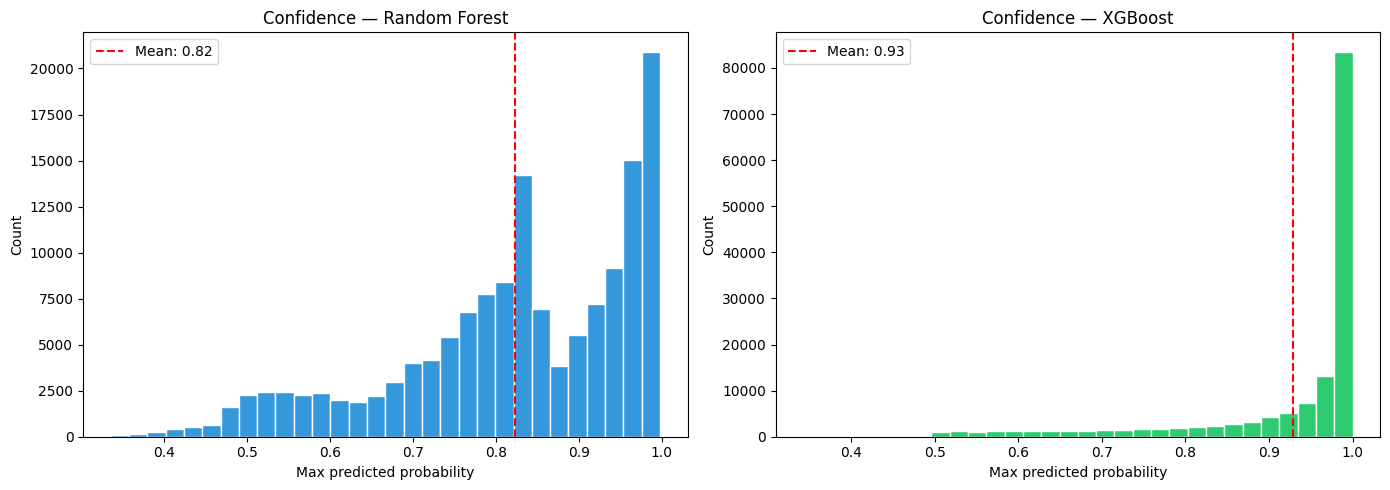

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prob, name, color in zip(
    axes,
    [rf_prob, xgb_prob],
    ["Random Forest", "XGBoost"],
    ["#3498db", "#2ecc71"]
):
    conf = prob.max(axis=1)
    ax.hist(conf, bins=30, color=color, edgecolor="white")
    ax.axvline(conf.mean(), color="red", linestyle="--",
               label=f"Mean: {conf.mean():.2f}")
    ax.set_title(f"Confidence — {name}")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

## 14. Save Best Model

Automatically pick the model with the higher weighted F1 and serialise it with `joblib`.

In [22]:
import joblib

best_row  = comparison.sort_values("Weighted F1", ascending=False).iloc[0]
best_name = best_row["Model"]
best_model = rf_model if best_name == "Random Forest" else xgb_model

print(f"Best model: {best_name}  (Weighted F1 = {best_row['Weighted F1']:.4f})")

joblib.dump(
    best_model,
    "opportunity_classifier_best.pkl"
)

print("Model saved \u2192 opportunity_classifier_best.pkl")



Best model: XGBoost  (Weighted F1 = 0.9433)
Model saved → opportunity_classifier_best.pkl
